In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [65]:
df = pd.read_csv("Expenses.csv")
df = df.drop([0, 1])
df

,Timestamp,Nama Pengeluaran,Kategori,Keterangan,Price
2,6/5/2024 15:41,Mie,Makanan,Sedap Soto,3500
3,6/5/2024 15:41,Telur,Makanan,Satu Biji,2500
4,6/5/2024 16:14,Malkist,Jajan,2 pcs,2000
5,7/5/2024 0:10,Lauk,Makanan,"Tempe, mie, telur",11000
6,7/5/2024 8:09,Bensin,Tranportasi,Tidak di pom,5000
7,7/5/2024 15:43,Nasi Padang,Makanan,Addition krupuk,14000
8,7/5/2024 23:22,Susu Frisant Flag,Jajan,Addition malkist,3000
9,8/5/2024 15:42,Sabun Daia,Lainnya,3 biji,3000
10,8/5/2024 15:43,Gooday,Jajan,Kue 2,3000
11,8/5/2024 22:24,Coca-cola,Jajan,Dingin 390ml,6000


In [63]:
df['Timestamp'] = pd.to_datetime(df['Time'])


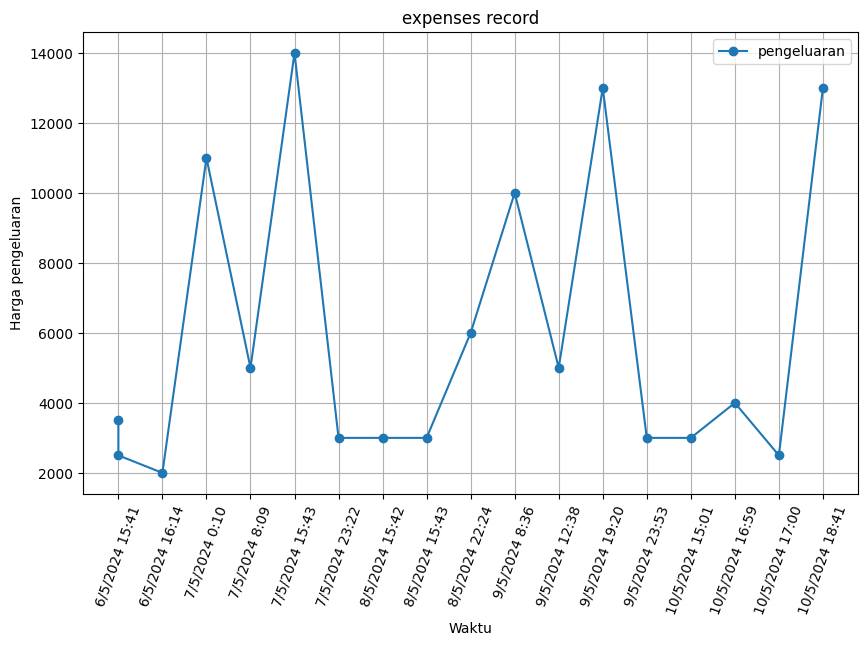

In [66]:
time = df['Timestamp']
y = df['Price']
plt.figure(figsize=(10, 6))
plt.plot(time, y, label='pengeluaran', marker='o',)

#manambahkan label dan judul
plt.xlabel('Waktu' )
plt.ylabel('Harga pengeluaran')
plt.title('expenses record')
plt.xticks(rotation=70)

plt.legend()
plt.grid(True)
plt.show()

In [67]:
dfx = df

In [81]:
#menghitung berapa bnyak kategori yang kategori yang sama
category = dfx['Kategori'].value_counts()
category

Kategori
Makanan        8
Jajan          7
Lainnya        2
Tranportasi    1
Name: count, dtype: int64

In [68]:
import pandas as pd
dfx['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract date into a new column
df['Date'] = df['Timestamp'].dt.date

# Extract time into a new column
df['Time'] = df['Timestamp'].dt.time

# Drop the original 'Timestamp' column if needed
dfx.drop('Timestamp', axis=1, inplace=True)

# Display the DataFrame with separated date and time columns
df

,Nama Pengeluaran,Kategori,Keterangan,Price,Date,Time
2,Mie,Makanan,Sedap Soto,3500,2024-06-05,15:41:00
3,Telur,Makanan,Satu Biji,2500,2024-06-05,15:41:00
4,Malkist,Jajan,2 pcs,2000,2024-06-05,16:14:00
5,Lauk,Makanan,"Tempe, mie, telur",11000,2024-07-05,00:10:00
6,Bensin,Tranportasi,Tidak di pom,5000,2024-07-05,08:09:00
7,Nasi Padang,Makanan,Addition krupuk,14000,2024-07-05,15:43:00
8,Susu Frisant Flag,Jajan,Addition malkist,3000,2024-07-05,23:22:00
9,Sabun Daia,Lainnya,3 biji,3000,2024-08-05,15:42:00
10,Gooday,Jajan,Kue 2,3000,2024-08-05,15:43:00
11,Coca-cola,Jajan,Dingin 390ml,6000,2024-08-05,22:24:00


In [89]:
#cek seberapa duit kita habiskan pada setiap kategori
grouped_data = dfx.groupby('Kategori')['Price'].sum()
#seberapa banyak transaksi 

tr = dfx.groupby('Date')['Price'].sum()


print(grouped_data)


print(tr)
print("jumlah yang dihabiskan dalam 5 hari terakhir : Rp ",tr.sum())

Kategori
Jajan          25000
Lainnya         7000
Makanan        69500
Tranportasi     5000
Name: Price, dtype: int64
Date
2024-06-05     8000
2024-07-05    33000
2024-08-05    12000
2024-09-05    31000
2024-10-05    22500
Name: Price, dtype: int64
jumlah yang dihabiskan dalam 5 hari terakhir : Rp  106500


In [78]:
tr.mean()

21300.0

[7182.00183733]
coefficient : [32.20853677]
mse : 26256821.90
coefficient of determination : -0.26


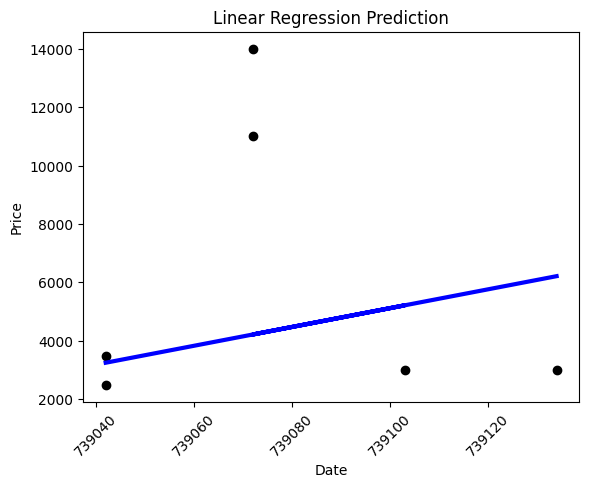

In [43]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import linear_model
import matplotlib.pyplot as plt

# Assuming 'Date' is the name of the column containing dates
X = dfx['Date'].apply(lambda x: x.toordinal()).values.reshape(-1, 1)

# Assuming 'Price' is the name of the column containing prices
y = dfx['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Create a linear regression object
regr = linear_model.LinearRegression()

regr.fit(X_train, y_train)



y_pred = regr.predict(X_test)
myx = [[739164]]
ypredx =regr.predict(myx)
print(ypredx)
print('coefficient :', regr.coef_)
print("mse : %.2f" % mean_squared_error(y_test, y_pred))
print("coefficient of determination : %.2f" % r2_score(y_test, y_pred))


plt.scatter(X_test, y_test, color ='black')
plt.plot(X_test, y_pred, color = 'blue', linewidth=3)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Linear Regression Prediction')
plt.show()



In [24]:
X

array([[739042],
       [739042],
       [739042],
       [739042],
       [739042],
       [739072],
       [739072],
       [739072],
       [739072],
       [739103],
       [739103],
       [739103],
       [739134],
       [739134],
       [739134],
       [739134],
       [739164],
       [739164],
       [739164],
       [739164]], dtype=int64)

In [19]:
from datetime import datetime

# Convert the target date to its ordinal representation

# Convert the date '2025-05-11' to its ordinal representation
date_conver= datetime(2024, 5, 20).toordinal()

# Reshape the date to match the shape required by predict() method
date = np.array(date_conver).reshape(-1, 1)

# Predict the price on May 11, 2025
predicted_price = regr.predict(date)

print("Predicted price on 2025-05-11:", predicted_price)

Predicted price on 2025-05-11: [45986.87759125]


In [12]:
date

array([[739018]])

In [ ]:
predictedCO2 = regr.predict([[3500, 1300]])

print(predictedCO2)

In [9]:
df.describe()

,Price
count,20.000000
mean,19150.000000
std,45565.770856
min,2000.000000
25%,3000.000000
50%,4500.000000
75%,11500.000000
max,200000.000000


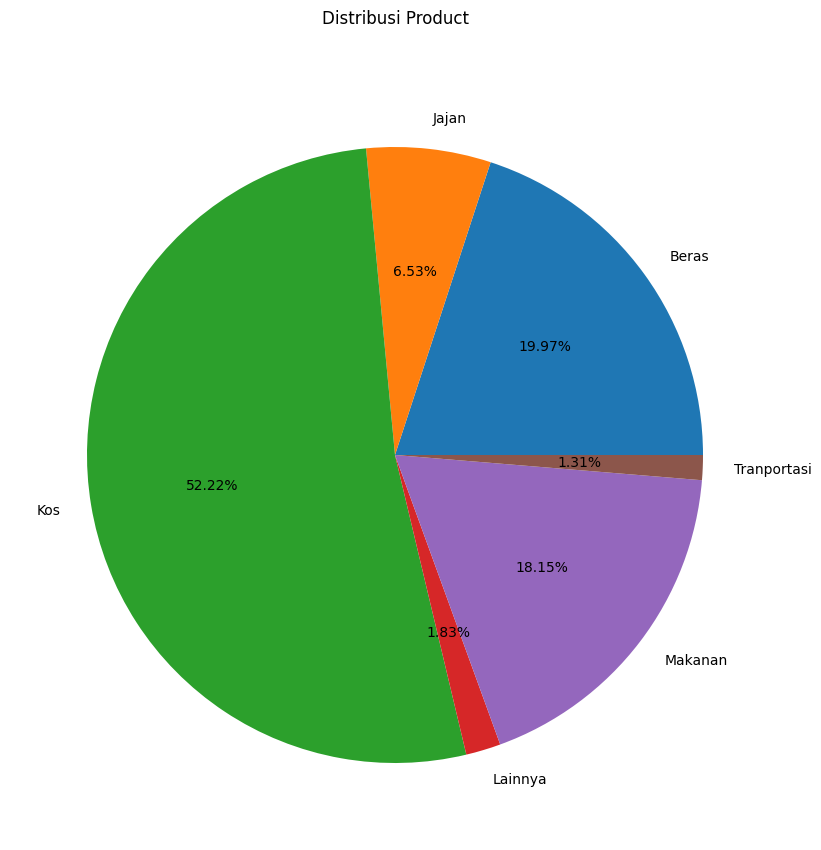

In [35]:
df.groupby('Kategori')['Price'].sum().plot(kind='pie', autopct='%1.2f%%', figsize=(10, 10))
plt.title("Distribusi Product", y=1.05)
plt.ylabel('')
plt.show()

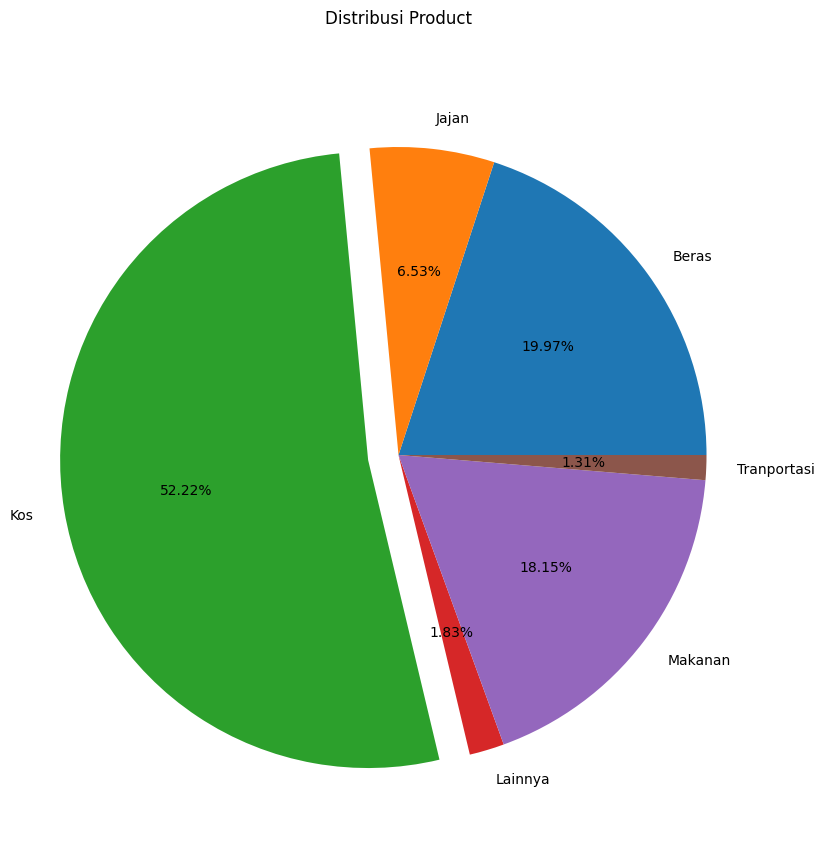

In [36]:
import matplotlib.pyplot as plt

# Assuming 'Kategori' is the name of the column containing categories and 'Price' is the name of the column containing prices
kategori_sum = df.groupby('Kategori')['Price'].sum()

# Extracting category with maximum price for explosion
max_category = kategori_sum.idxmax()

# Create explode list
explode = [0.1 if kategori == max_category else 0 for kategori in kategori_sum.index]

kategori_sum.plot(kind='pie', autopct='%1.2f%%', figsize=(10, 10), explode=explode)
plt.title("Distribusi Product", y=1.05)
plt.ylabel('')
plt.show()



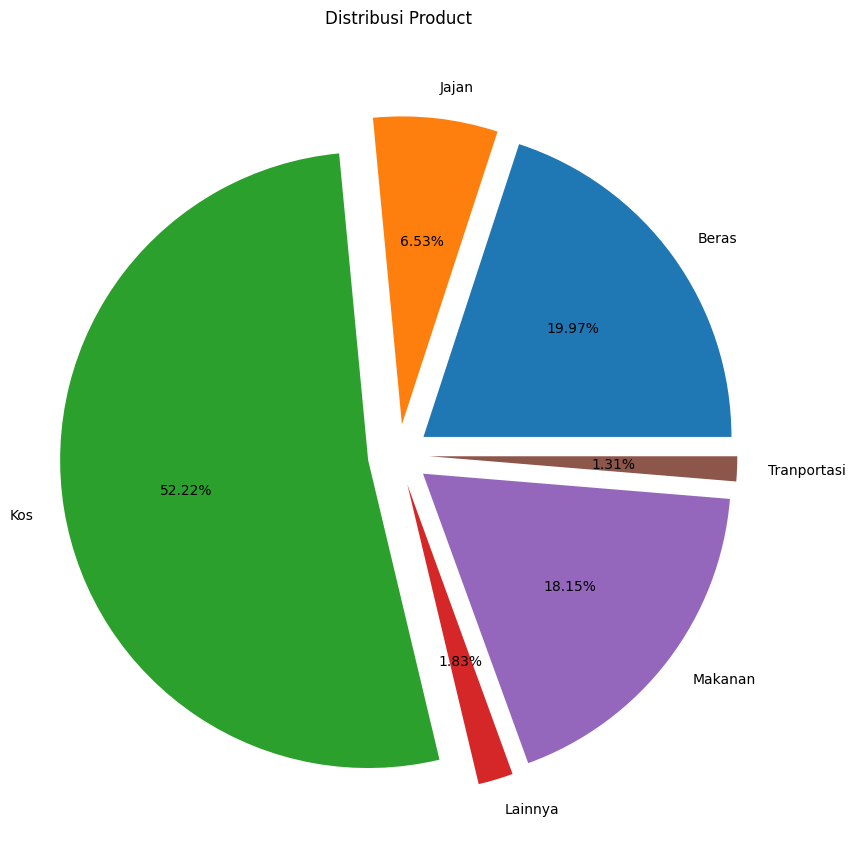

In [37]:


# Assuming 'Kategori' is the name of the column containing categories and 'Price' is the name of the column containing prices
kategori_sum = df.groupby('Kategori')['Price'].sum()

# Create explode list
explode = [0.1] * len(kategori_sum)

kategori_sum.plot(kind='pie', autopct='%1.2f%%', figsize=(10, 10), explode=explode)
plt.title("Distribusi Product", y=1.05)
plt.ylabel('')
plt.show()


In [21]:
X

array(['Beras', 'Kos', 'Makanan', 'Jajan', 'Tranportasi', 'Lainnya'],
      dtype=object)

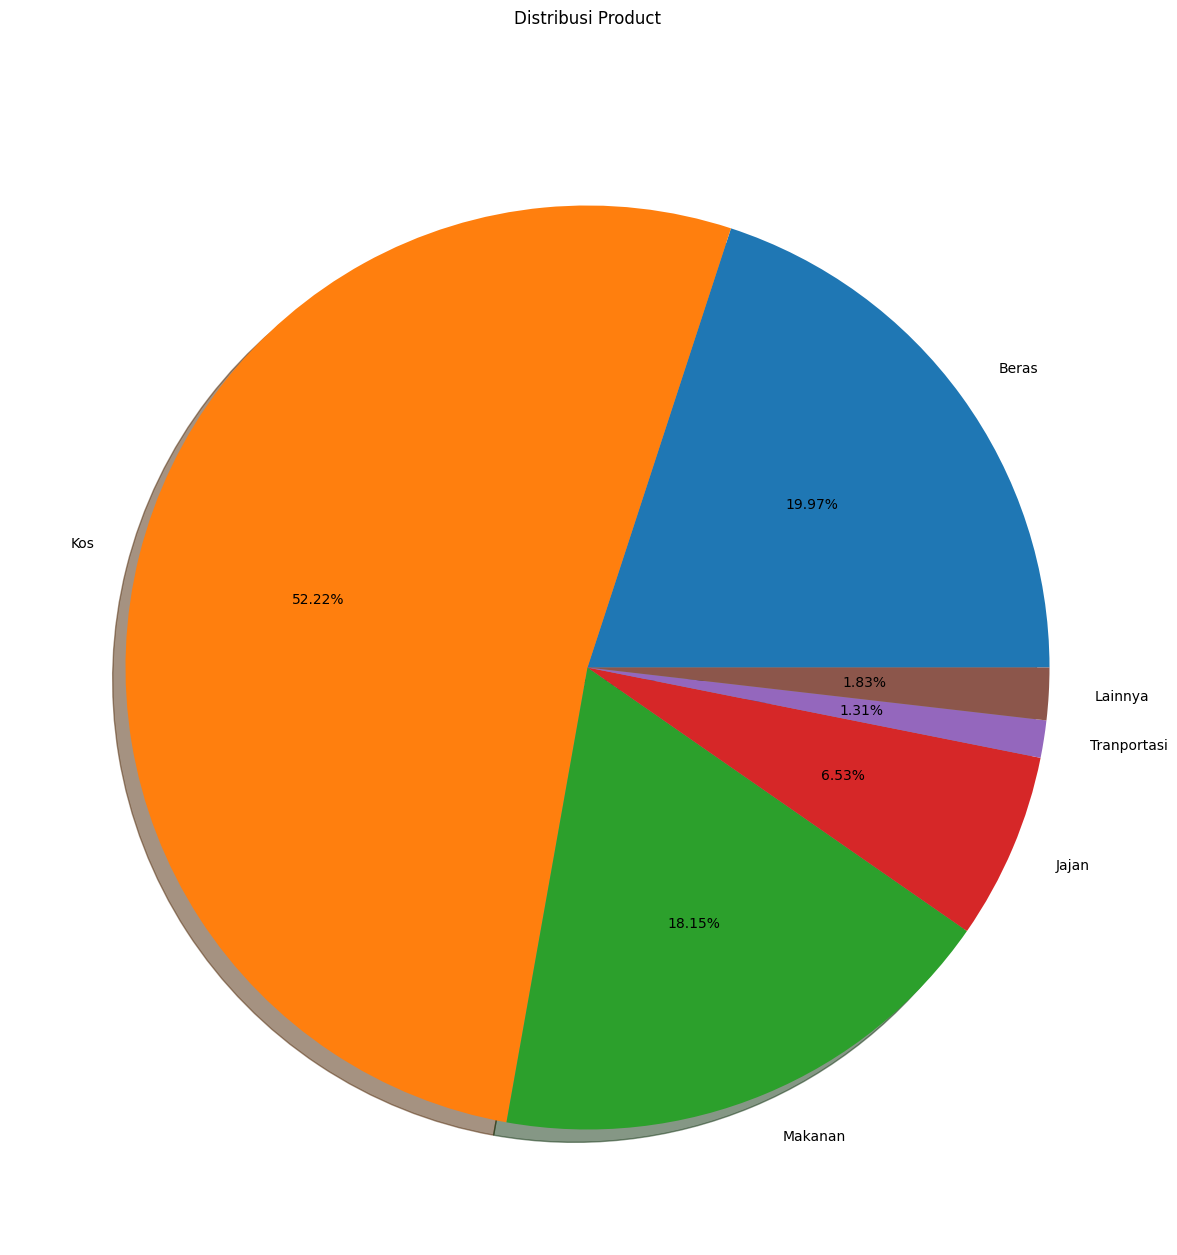

In [33]:

plt.figure(figsize=(15, 15))
plt.title("Distribusi Product", y=1.05)

plt.pie(
    y,
    labels=X,
    autopct='%1.2f%%',
    shadow=True,
)
plt.show()

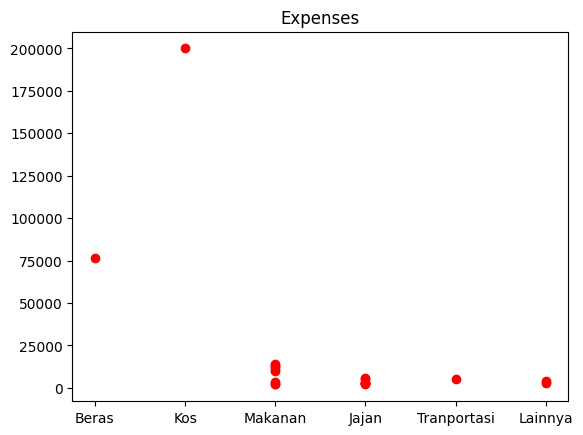

In [7]:
plt.s(X, y, color='red')
plt.title('Expenses')
plt.show()

In [5]:
X = df[['Weight', 'Volume']]
y = df['CO2']

In [6]:
from sklearn import linear_model

regr = linear_model.LinearRegression()
regr.fit(X, y)


LinearRegression()

In [7]:
predictedCO2 = regr.predict([[3500, 1300]])

print(predictedCO2)

[116.26986952]


d:\DataScience\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [8]:
ini = df['Weight']

std= np.var(ini)
print(std)

56995.53395061728


In [9]:
import math
variance = math.sqrt(std)
print(variance)

238.73737443185826


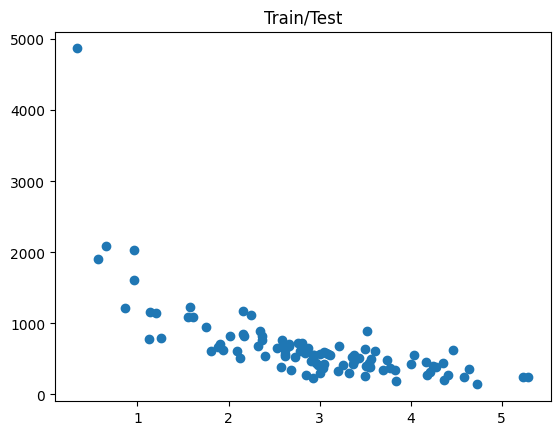

In [20]:
np.random.seed(2)

p = np.random.normal(3,1, 100)
q = np.random.normal(1500,400 ,100)/p

plt.scatter(p, q)
plt.title('Train/Test')

plt.show()

In [29]:
train_p = p[:80]
train_q = q[:80]

test_p = p[80:]
test_q = q[80:]


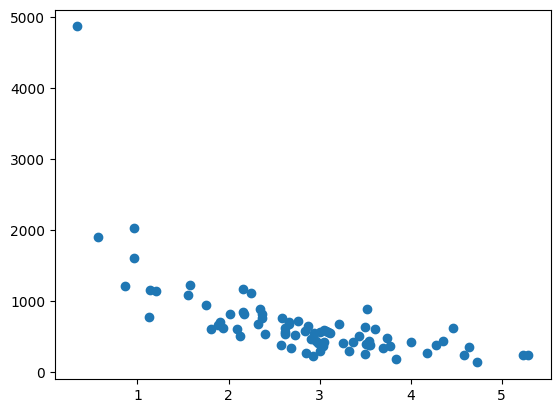

In [32]:
plt.scatter(train_p, train_q)
plt.show()

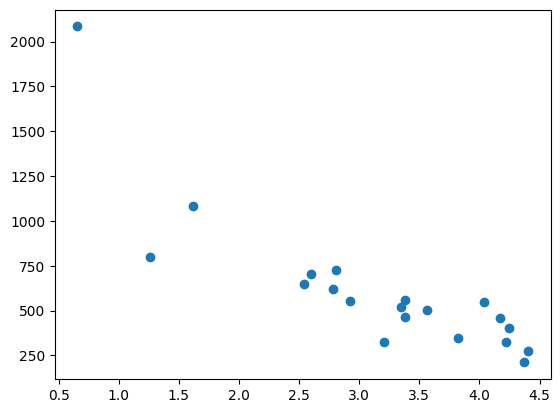

In [33]:
plt.scatter(test_p, test_q)
plt.show()

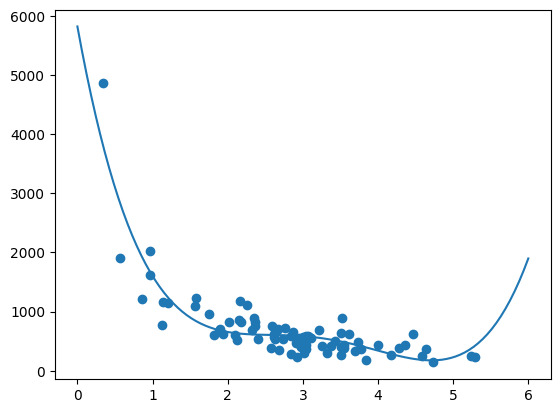

In [34]:
mymodel = np.poly1d(np.polyfit(train_p, train_q, 4))
myline = np.linspace(0,6, 100)
plt.scatter(train_p, train_q)
plt.plot(myline, mymodel(myline))
plt.show()

In [38]:
from sklearn.metrics import r2_score
r2 = r2_score(train_q, mymodel(train_p))
print(r2)

0.7988645544629795


In [39]:
r2_test = r2_score(test_q, mymodel(test_p))
print(r2_test)

0.8086921460343584


In [40]:
print(mymodel(2))

656.0710153026221


**skykit learn**

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score



In [2]:
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)

In [ ]:
diabetes_X = diabetes_X[:, np.newaxis, 2]

diabetes_X_train = diabetes_X[:-20]
diabetes_x_test = diabetes_y[-20:]

diabetes_y_train = diabetes_y[:-20]
diabetes_y_test = diabetes_y[-20:]
regr = linear_model.LinearRegression()

regr.fit(diabetes_X_train, diabetes_y_train)

diabetes_y_pred = regr.predict(diabetes_X_test)
